# Option pricing
Project for the Introduction to Financial Engineering class.

In [1]:
from bin_model import BinomialModel, get_up_factor, get_down_factor
from options import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt = 1 / 12
sigma = 0.3
u = get_up_factor(sigma, dt)
d = get_down_factor(sigma, dt)
S0 = 50
r = 0.02
K = 48
T = 2

N = int(T / dt) # number of periods
bin_model = BinomialModel(S0, N, dt, u, d, r)

## European options

In [3]:
eur_call = EuropeanCall(K)
eur_put = EuropeanPut(K)

eur_call_price = eur_call.price(bin_model)
eur_put_price = eur_put.price(bin_model)
print(f'European call price: {eur_call_price:.3f}')
print(f'European put price: {eur_put_price:.3f}')

European call price: 10.191
European put price: 6.309


## American options

In [4]:
ame_call = AmericanCall(K)
ame_put = AmericanPut(K)

ame_call_price = ame_call.price(bin_model)
ame_put_price = ame_put.price(bin_model)
print(f'American call price: {ame_call_price:.3f}')
print(f'American put price: {ame_put_price:.3f}')

American call price: 10.191
American put price: 6.471


## Theoretical properties checks

#### Put call parity
$$C_E + Ke^{-r * T} = P_E + S_0$$

In [5]:
lhs = eur_call_price + K * np.exp(-r * T)
rhs = eur_put_price + S0
print('put-call parity:', np.abs(lhs - rhs) < 1e-10)

put-call parity: True


#### Upper and lower bounds
European options:
$$S_0 - Ke^{-rT} \leq C_E \leq S_0,$$
$$Ke^{-rT} - S_0 \leq P_E \leq  Ke^{-rT}.$$

American options:
$$S_0-Ke^{-rT} \leq C_A \leq S_0,$$
$$K-S_0 \leq P_A \leq K.$$

In [6]:
eur_call_low = max(S0 - K * np.exp(-r * T), 0)
eur_call_hi = S0
print('European call bounds:', eur_call_low <= eur_call_price <= eur_call_hi)

eur_put_low = max(K * np.exp(-r * T) - S0, 0)
eur_put_hi = K * np.exp(-r * T)
print('European put bounds:', eur_put_low <= eur_put_price <= eur_put_hi)

ame_call_low = max(S0 - K * np.exp(-r * T), 0)
ame_call_hi = S0
print('European call bounds:', ame_call_low <= ame_call_price <= ame_call_hi)

ame_put_low = max(K - S0, 0)
ame_put_hi = K
print('European put bounds:', ame_put_low <= ame_put_price <= ame_put_hi)

European call bounds: True
European put bounds: True
European call bounds: True
European put bounds: True


## American vs. European comparison
We expect $C_A = C_E$ and $P_A \geq P_E$.

In [7]:
print('Equality in call prices:', abs(eur_call_price - ame_call_price) < 1e-6)
print('Amerian put more expensive than European:', ame_put_price >= eur_put_price)

Equality in call prices: True
Amerian put more expensive than European: True


## Sensitivity analysis
Analiza wrażliwości ceny wszystkich tych 4 rodzajów opcji ze względu na cenę wykonania K,
zapadalność T oraz parametry S0, σ i r (tzn.zbadanie,jak różne wartości tych parametróww pływają
na ceny tych opcji, w jak dużym stopniu, czy można zaobserwować pewne monotoniczności itp.).

In [8]:
# Base case parameters
BASE_S0 = 100
BASE_K = 100
BASE_T = 1.0
BASE_R = 0.05
BASE_SIGMA = 0.20
BASE_N = 100

In [9]:
def analyze_sensitivity(param_name, param_values):
    eur_calls, eur_puts = [], []
    ame_calls, ame_puts = [], []
    
    for val in param_values:
        s0 = val if param_name == 'S0' else BASE_S0
        k = val if param_name == 'K' else BASE_K
        t = val if param_name == 'T' else BASE_T
        r = val if param_name == 'r' else BASE_R
        sigma = val if param_name == 'sigma' else BASE_SIGMA
        
        dt = t / BASE_N
        u = get_up_factor(sigma, dt)
        d = get_down_factor(sigma, dt)
        
        model = BinomialModel(S0=s0, N=BASE_N, dt=dt, u=u, d=d, r=r)
        
        eur_calls.append(EuropeanCall(K=k).price(model))
        eur_puts.append(EuropeanPut(K=k).price(model))
        ame_calls.append(AmericanCall(K=k).price(model))
        ame_puts.append(AmericanPut(K=k).price(model))

    plt.figure(figsize=(10, 6))
    plt.plot(param_values, eur_calls, label='European Call', linestyle='-')
    plt.plot(param_values, ame_calls, label='American Call', linestyle='--')
    plt.plot(param_values, eur_puts, label='European Put', linestyle='-')
    plt.plot(param_values, ame_puts, label='American Put', linestyle='--')
    
    plt.title(f'Option Prices vs {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('Option Price')
    plt.legend()
    plt.grid(True)
    plt.show()

### Sensitivity to stock price, $S_0$

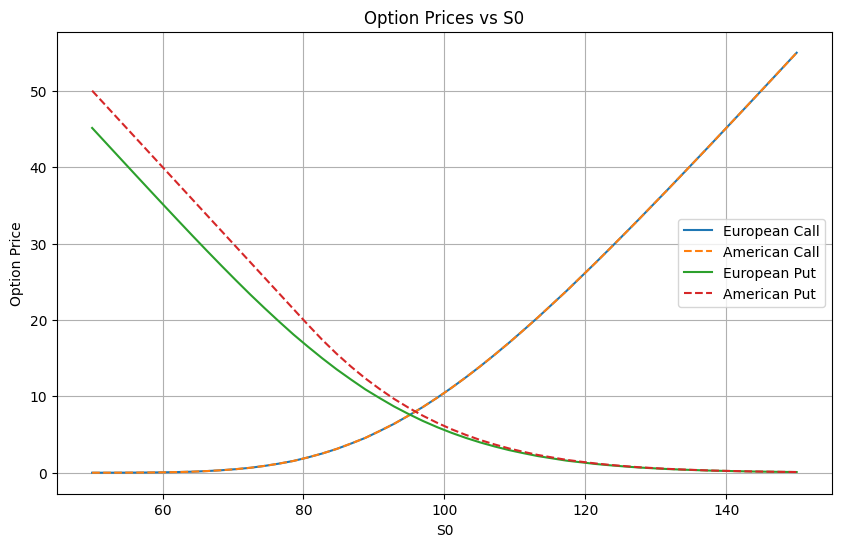

In [10]:
analyze_sensitivity('S0', np.linspace(50, 150, 50))

### Sensitivity to strike price $K$

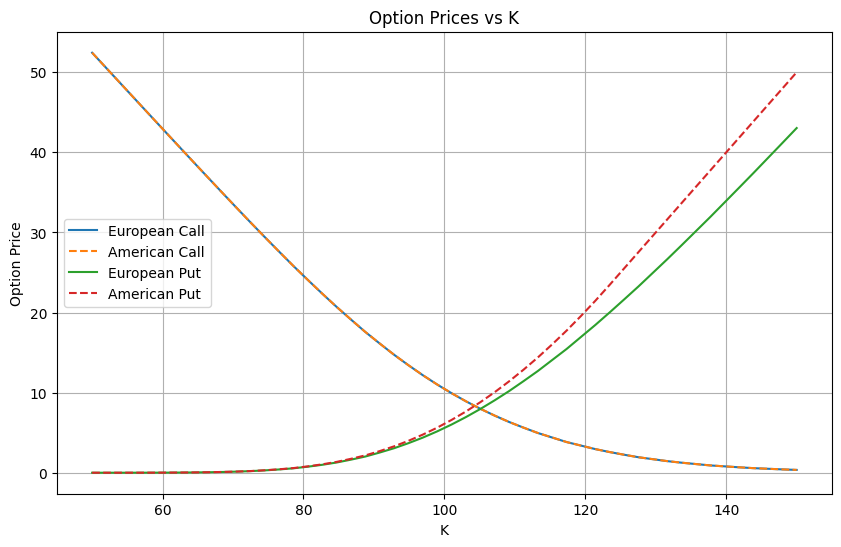

In [11]:
analyze_sensitivity('K', np.linspace(50, 150, 50))

### Sensitivity to time to maturity $T$

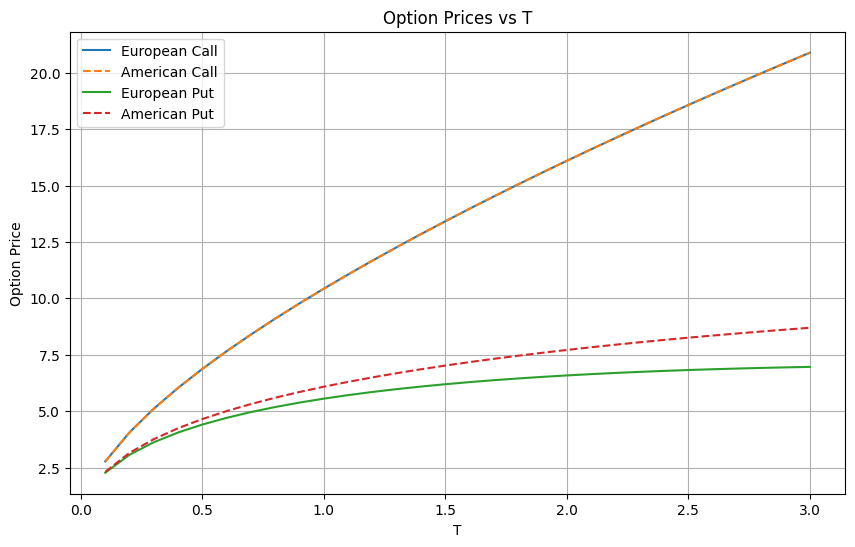

In [12]:
analyze_sensitivity('T', np.linspace(0.1, 3.0, 30))

### Sensitivity to volatility $\sigma$

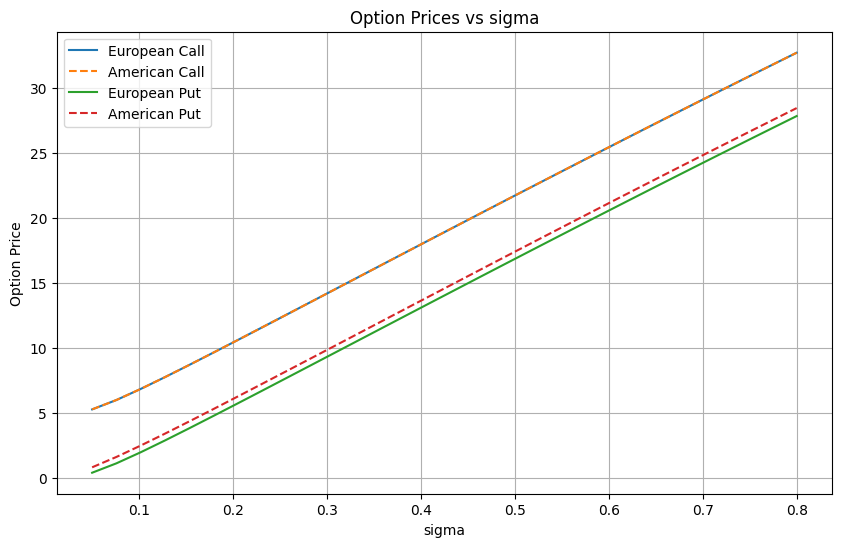

In [13]:
analyze_sensitivity('sigma', np.linspace(0.05, 0.80, 30))

### Sensitivity to Interest Rate ($r$)

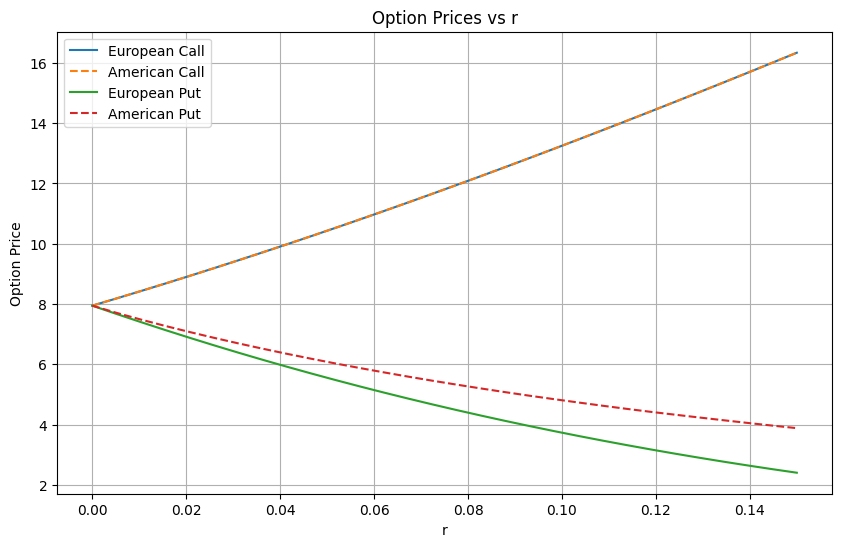

In [14]:
analyze_sensitivity('r', np.linspace(0.0, 0.15, 30))

// TODO: These are AI, do a proper analysis.
*   **Stock Price ($S_0$):** Calls are **monotonically increasing** (as stock goes up, right to buy is worth more). Puts are **monotonically decreasing**.
*   **Strike Price ($K$):** Calls are **monotonically decreasing** (higher strike means you pay more to buy the stock). Puts are **monotonically increasing**.
*   **Volatility ($\sigma$):** All 4 option types are **monotonically increasing** relative to volatility. Volatility means more uncertainty, which increases the chance of massive upside while the option's downside remains strictly capped at $0. 
*   **Interest Rate ($r$):** Higher rates increase Call values (because paying the strike price in the future means you save money today via discounting) and decrease Put values. 
*   **American vs. European Gaps:** Pay special attention to the Put lines. As $T$ gets larger, or $r$ gets higher, you should see the **American Put line pull away and become noticeably more expensive than the European Put line**. Explain that this visual gap represents the "early exercise premium." Meanwhile, the American and European call lines should remain perfectly identical.

## Convergence analysis (sensitivity to the number of periods)

In [15]:
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
N_start, N_end = 5, 200

In [16]:
def generate_prices(option_class, S0, T, r, sigma, N_start, N_end):
    N_values = list(range(N_start, N_end))
    dt_values = [T / N for N in N_values]
    opt_prices = []

    for N in N_values:
        dt = T / N
        u = get_up_factor(sigma, dt)
        d = get_down_factor(sigma, dt)
        
        model = BinomialModel(S0=S0, N=N, dt=dt, u=u, d=d, r=r)
        opt_prices.append(option_class(K=K).price(model))

    return N_values, dt_values, opt_prices

In [17]:
def analyze_convergence(N_values, dt_values, bin_model_prices, bs_price=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(N_values, bin_model_prices, label='Binomial Tree', color='blue')
    if bs_price is not None:
        plt.axhline(y=bs_price, color='red', linestyle='--', label='Black-Scholes')
    plt.xlabel('Number of Steps (N)')
    plt.ylabel('Option Price')
    plt.title('Convergence vs. N')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(dt_values, bin_model_prices, label='Binomial Tree', color='blue')
    if bs_price is not None:
        plt.axhline(y=bs_price, color='red', linestyle='--', label='Black-Scholes')
    plt.xlabel(r'Time Step ($\Delta t$)')
    plt.gca().invert_xaxis() # invert x-axis
    plt.ylabel('Option Price')
    plt.title(r'Convergence vs. $\Delta t$')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### European call

In [18]:
from scipy.stats import norm

# reference: https://en.wikipedia.org/wiki/Black–Scholes_model#Black–Scholes_formula
def black_scholes_european_call(S0, K, T, r, sigma):
    d_plus = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d_minus = d_plus - sigma * np.sqrt(T)
    return S0 * norm.cdf(d_plus) - K * np.exp(-r * T) * norm.cdf(d_minus)

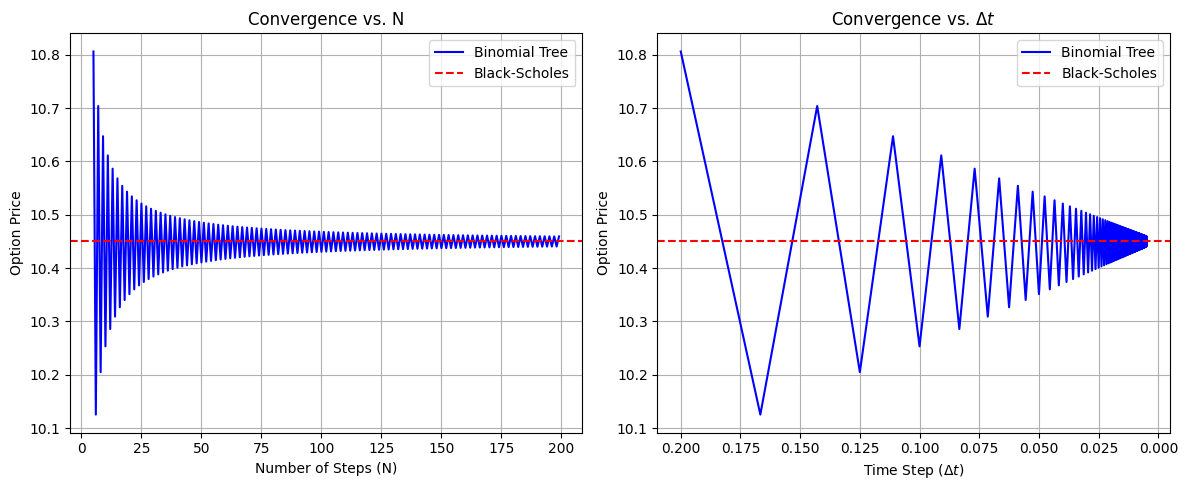

In [19]:
bs_call_price = black_scholes_european_call(S0, K, T, r, sigma)
N_values, dt_values, eur_call_prices = generate_prices(EuropeanCall, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, eur_call_prices, bs_call_price)

### European put

In [20]:
# reference: https://en.wikipedia.org/wiki/Black–Scholes_model#Black–Scholes_formula
def black_scholes_european_put(S0, K, T, r, sigma):
    return K * np.exp(-r * T) - S0 + black_scholes_european_call(S0, K, T, r, sigma)

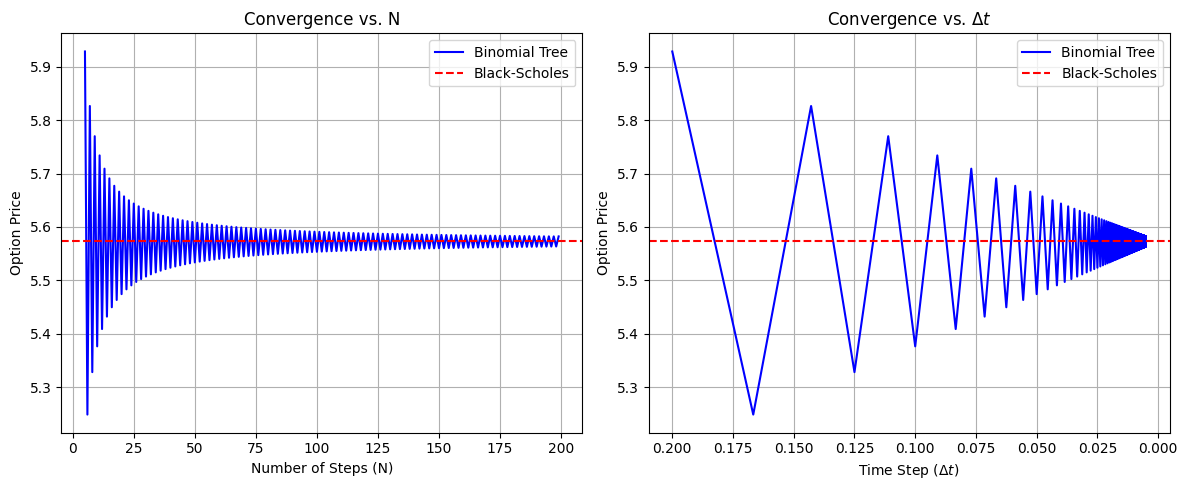

In [21]:
bs_put_price = black_scholes_european_put(S0, K, T, r, sigma)
N_values, dt_values, eur_put_prices = generate_prices(EuropeanPut, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, eur_put_prices, bs_put_price)

### American call

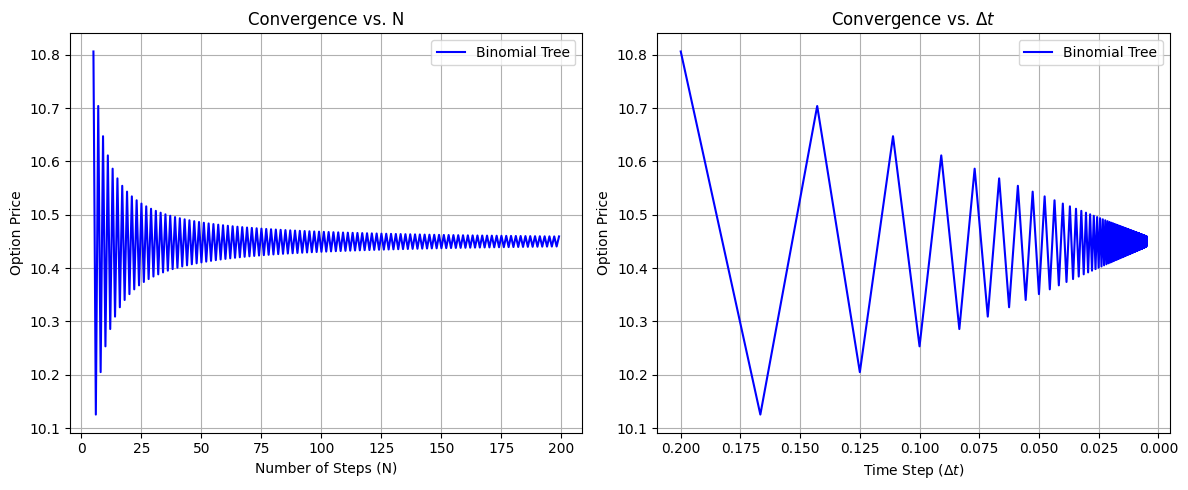

In [22]:
N_values, dt_values, ame_call_prices = generate_prices(AmericanCall, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, ame_call_prices)

### American put

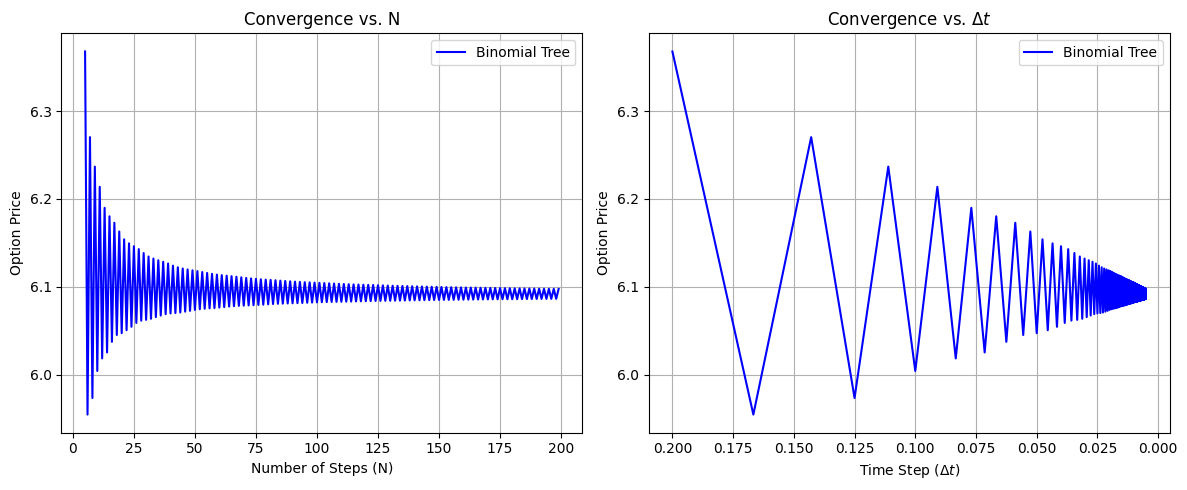

In [23]:
N_values, dt_values, ame_put_prices = generate_prices(AmericanPut, S0, T, r, sigma, N_start, N_end)
analyze_convergence(N_values, dt_values, ame_put_prices)